# Упражнение 2.3 

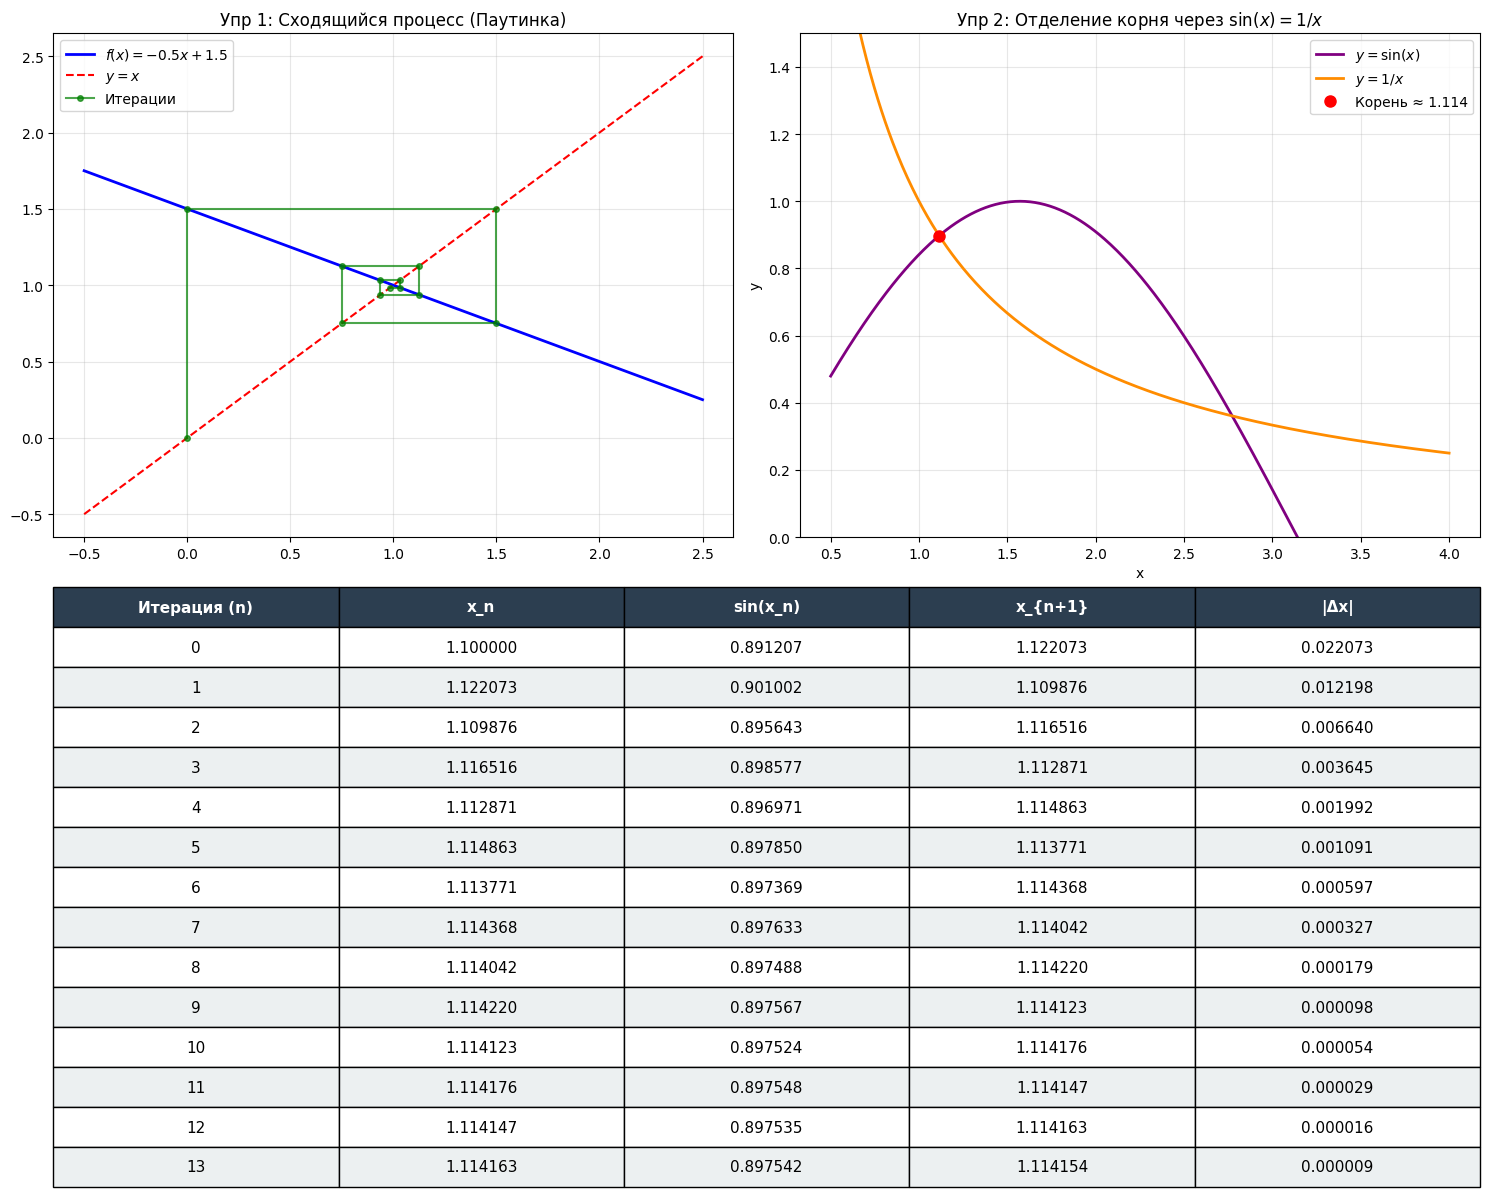

Корень найден: 1.11415


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

# Настраиваем общее полотно: 2 строки, 2 столбца
fig = plt.figure(figsize=(15, 12))
ax1 = plt.subplot(2, 2, 1)  # Упр 1 (Паутинка)
ax2 = plt.subplot(2, 2, 2)  # Упр 2 (Отделение корня: sin(x) vs 1/x)
ax3 = plt.subplot(2, 1, 2)  # Упр 2 (Таблица результатов)

# ==========================================
# Упражнение 1: Графическая иллюстрация (-1 < f'(x) < 0)
# ==========================================
def f1(x):
    return -0.5 * x + 1.5

x_vals1 = np.linspace(-0.5, 2.5, 400)
ax1.plot(x_vals1, f1(x_vals1), label=r"$f(x) = -0.5x + 1.5$", color="blue", lw=2)
ax1.plot(x_vals1, x_vals1, label=r"$y = x$", color="red", ls="--")

# Процесс итераций
x_p, y_p = [0.0], [0]
for _ in range(6):
    x_next = f1(x_p[-1])
    x_p.extend([x_p[-1], x_next])
    y_p.extend([x_next, x_next])

ax1.plot(x_p, y_p, color="green", marker="o", ms=4, alpha=0.7, label="Итерации")
ax1.set_title("Упр 1: Сходящийся процесс (Паутинка)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# ==========================================
# Упражнение 2: Графическое отделение корня (sin x = 1/x)
# ==========================================
# Берем диапазон чуть дальше 0, чтобы избежать деления на ноль
x_vals2 = np.linspace(0.5, 4, 500)
y_sin = np.sin(x_vals2)
y_hyperbola = 1 / x_vals2

ax2.plot(x_vals2, y_sin, label=r"$y = \sin(x)$", color="purple", lw=2)
ax2.plot(x_vals2, y_hyperbola, label=r"$y = 1/x$", color="darkorange", lw=2)

# Отмечаем корень
root_approx = 1.114157
ax2.plot(root_approx, np.sin(root_approx), 'ro', ms=8, label=f"Корень ≈ {root_approx:.3f}")

ax2.set_title(r"Упр 2: Отделение корня через $\sin(x) = 1/x$")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_ylim(0, 1.5) # Ограничим по высоте для наглядности
ax2.grid(True, alpha=0.3)
ax2.legend()

# ==========================================
# Упражнение 2: Расчет и Таблица Pandas
# ==========================================
def phi(x):
    return 1 / math.sin(x)

x_curr = 1.1
eps = 1e-5
rows = []
n = 0

while True:
    x_next = phi(x_curr)
    diff = abs(x_next - x_curr)
    
    rows.append({
        "Итерация (n)": n,
        "x_n": f"{x_curr:.6f}",
        "sin(x_n)": f"{math.sin(x_curr):.6f}",
        "x_{n+1}": f"{x_next:.6f}",
        "|Δx|": f"{diff:.6f}"
    })
    
    if diff < eps:
        break
    x_curr = x_next
    n += 1

df = pd.DataFrame(rows)

# Отрисовка таблицы
ax3.axis("off")

the_table = ax3.table(
    cellText=df.values, 
    colLabels=df.columns, 
    loc="center", 
    cellLoc="center"
)

# Стилизация таблицы
the_table.auto_set_font_size(False)
the_table.set_fontsize(11)
the_table.scale(1, 2)

# Цветовое оформление шапки и строк
for (row, col), cell in the_table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')

plt.tight_layout()
plt.show()

print(f"Корень найден: {x_next:.5f}")

# Упражнение 2.5 

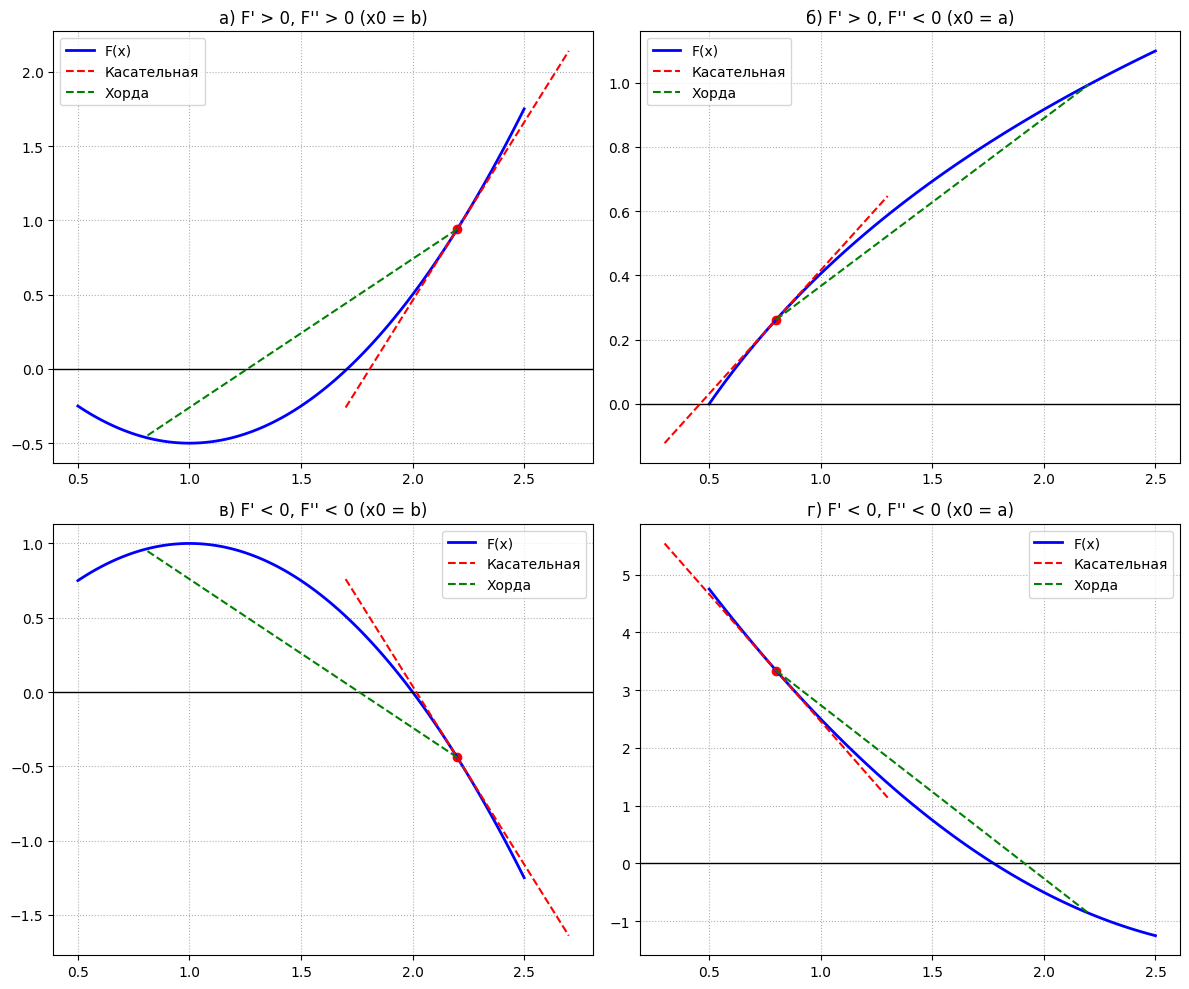

In [ ]:
def plot_methods():
    # Настройка области рисования (2x2)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    x = linspace(0.5, 2.5, 100)
    
    # 1. Возрастает, выпукла вниз (F' > 0, F'' > 0) -> x0 = b 
    f1 = lambda x: (x - 1)**2 - 0.5
    df1 = lambda x: 2*(x - 1)
    # 2. Возрастает, выпукла вверх (F' > 0, F'' < 0) -> x0 = a 
    f2 = lambda x: log(x + 0.5)
    df2 = lambda x: 1/(x + 0.5)
    # 3. Убывает, выпукла вверх (F' < 0, F'' < 0) -> x0 = b 
    f3 = lambda x: -((x - 1)**2) + 1
    df3 = lambda x: -2*(x - 1)
    # 4. Убывает, выпукла вниз (F' < 0, F'' > 0) -> x0 = a 
    f4 = lambda x: (3 - x)**2 - 1.5
    df4 = lambda x: -2*(3 - x)

    cases = [
        (f1, df1, "а) F' > 0, F'' > 0 (x0 = b)", 'right'),
        (f2, df2, "б) F' > 0, F'' < 0 (x0 = a)", 'left'),
        (f3, df3, "в) F' < 0, F'' < 0 (x0 = b)", 'right'),
        (f4, df4, "г) F' < 0, F'' < 0 (x0 = a)", 'left')
    ]

    for i, (f, df, title, side) in enumerate(cases):
        ax = axs[i//2, i%2]
        ax.plot(x, f(x), 'b', label='F(x)', lw=2)
        ax.axhline(0, color='black', lw=1)
        
        a, b = 0.8, 2.2
        root = 1.5 # примерный корень для визуализации
        
        if side == 'right':
            x0, c, other = b, b, a
        else:
            x0, c, other = a, a, b
            
        # Касательная 
        tan_x = linspace(x0 - 0.5, x0 + 0.5, 10)
        tan_y = f(x0) + df(x0)*(tan_x - x0)
        ax.plot(tan_x, tan_y, 'r--', label='Касательная')
        
        # Хорда [cite: 147]
        ax.plot([c, other], [f(c), f(other)], 'g--', label='Хорда')
        
        ax.scatter([x0], [f(x0)], color='red')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

plot_methods()

In [18]:
def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    return 3*x**2 + 6*x - 24

def solve_combined(a, b, eps):
    data = []
    iteration = 0
    
    # Т.к. f' < 0 и f'' > 0 на [0, 1]:
    # a_next вычисляется методом касательных
    # b_next вычисляется методом хорд
    
    while abs(b - a) > eps:
        iteration += 1
        
        # Сохраняем текущие значения
        data.append({
            'Итерация': iteration,
            'a (касательные)': a,
            'b (хорды)': b,
            'f(a)': f(a),
            'f(b)': f(b),
            '|b - a|': abs(b - a)
        })
        
        # Уточнение границы a методом касательных
        a_next = a - f(a) / df(a)
        
        # Уточнение границы b методом хорд
        b_next = b - (f(b) * (b - a)) / (f(b) - f(a))
        
        a, b = a_next, b_next
        
        if iteration > 20:  # Предохранитель
            break

    return pd.DataFrame(data), (a + b) / 2

# Начальные данные
a_0, b_0 = 0.0, 1.0
eps = 0.000001

df_res, root = solve_combined(a_0, b_0, eps)

# Вывод результатов
pd.options.display.float_format = '{:.8f}'.format
display(df_res)
print(f"\nУточненный корень: {root:.7f}")

,Итерация,a (касательные),b (хорды),f(a),f(b),|b - a|
0,1,0.00000000,1.00000000,1.00000000,-19.00000000,1.00000000
1,2,0.04166667,0.05000000,0.00528067,-0.19237500,0.00833333



Уточненный корень: 0.0418892


# СР

1 задание

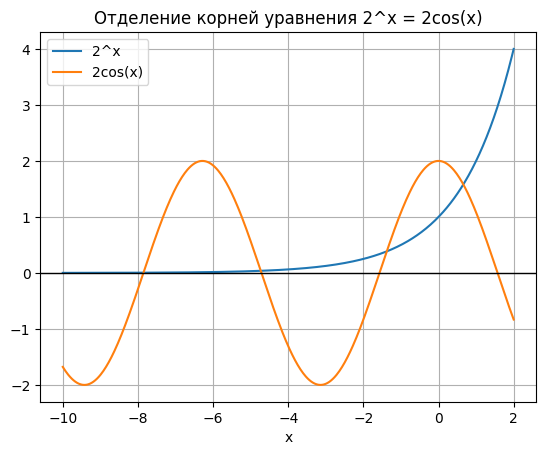

In [26]:


# Создаем данные для графика
x = linspace(-10, 2, 500)
y1 = 2**x
y2 = 2 * cos(x)

# Используем Pandas для структуры (как просили в условии)
df = pd.DataFrame({'x': x, '2^x': y1, '2cos(x)': y2})

# Построение
df.plot(x='x', grid=True, title='Отделение корней уравнения 2^x = 2cos(x)')
axhline(0, color='black', linewidth=1)
show()

2 задание

In [28]:
from numpy import *
import pandas as pd

# 1. Определение функции
def f(x):
    return 2**x - 2*cos(x)

# 2. Параметры метода
a = 0.0
b = 1.0
eps = 0.001

# Список для хранения данных итераций
data = []

# 3. Алгоритм метода половинного деления
def bisection(a, b, eps):
    if f(a) * f(b) >= 0:
        print("Метод неприменим: f(a) и f(b) должны иметь разные знаки.")
        return None
    
    n = 0
    while (b - a) / 2 > eps:
        n += 1
        c = (a + b) / 2
        f_c = f(c)
        
        # Сохраняем данные текущей итерации
        data.append({
            'Итерация': n,
            'a': round(a, 4),
            'b': round(b, 4),
            'x (середина)': round(c, 4),
            'f(x)': round(f_c, 4),
            'Погрешность': round((b - a) / 2, 4)
        })
        
        # Выбор новой половины интервала
        if f(a) * f_c < 0:
            b = c
        else:
            a = c
            
    return (a + b) / 2

# Вычисление
root = bisection(a, b, eps)

# 4. Вывод результатов через Pandas
if root is not None:
    df_results = pd.DataFrame(data)
    print("Таблица уточнения корня:")
    print(df_results.to_string(index=False))
    print(f"\nПриблизительный корень уравнения: x ≈ {root:.4f}")

Таблица уточнения корня:
 Итерация          a          b  x (середина)        f(x)  Погрешность
        1 0.00000000 1.00000000    0.50000000 -0.34100000   0.50000000
        2 0.50000000 1.00000000    0.75000000  0.21840000   0.25000000
        3 0.50000000 0.75000000    0.62500000 -0.07970000   0.12500000
        4 0.62500000 0.75000000    0.68750000  0.06480000   0.06250000
        5 0.62500000 0.68750000    0.65620000 -0.00860000   0.03120000
        6 0.65620000 0.68750000    0.67190000  0.02780000   0.01560000
        7 0.65620000 0.67190000    0.66410000  0.00950000   0.00780000
        8 0.65620000 0.66410000    0.66020000  0.00050000   0.00390000
        9 0.65620000 0.66020000    0.65820000 -0.00410000   0.00200000

Приблизительный корень уравнения: x ≈ 0.6592


3 задание

In [ ]:
# Исходная функция f(x)
def f(x):
    return 2**x - 2*cos(x)

# Преобразованная функция x = phi(x)
# phi(x) = log2(2 * cos(x))
def phi(x):
    return log2(2 * cos(x))

# Параметры
x0 = 0.5  # Начальное приближение на отрезке [0, 1]
eps = 0.001
data = []

# Алгоритм простой итерации
def simple_iteration(x_prev, eps):
    n = 0
    while True:
        n += 1
        x_curr = phi(x_prev)
        diff = abs(x_curr - x_prev)
        
        data.append({
            'Итерация': n,
            'x_n': round(x_prev, 5),
            'x_{n+1}': round(x_curr, 5),
            '|x_{n+1} - x_n|': round(diff, 5)
        })
        
        if diff < eps:
            break
        x_prev = x_curr
        
        if n > 100: # Защита от бесконечного цикла
            print("Метод не сходится")
            break
            
    return x_curr

# Вычисление
root = simple_iteration(x0, eps)

# Вывод таблицы
df = pd.DataFrame(data)
print("Метод простой итерации:")
print(df.to_string(index=False))
print(f"\nНайденный корень: x ≈ {root:.4f}")

Метод не сходится
Метод простой итерации:
 Итерация        x_n    x_{n+1}  |x_{n+1} - x_n|
        1 0.50000000 0.81161000       0.31161000
        2 0.81161000 0.46118000       0.35043000
        3 0.46118000 0.84081000       0.37963000
        4 0.84081000 0.41545000       0.42536000
        5 0.41545000 0.87174000       0.45628000
        6 0.87174000 0.36401000       0.50773000
        7 0.36401000 0.90223000       0.53823000
        8 0.90223000 0.31001000       0.59222000
        9 0.31001000 0.92953000       0.61952000
       10 0.92953000 0.25872000       0.67081000
       11 0.25872000 0.95117000       0.69245000
       12 0.95117000 0.21595000       0.73522000
       13 0.21595000 0.96610000       0.75015000
       14 0.96610000 0.18527000       0.78083000
       15 0.18527000 0.97510000       0.78983000
       16 0.97510000 0.16630000       0.80880000
       17 0.16630000 0.97996000       0.81366000
       18 0.97996000 0.15590000       0.82406000
       19 0.15590000 0.9824

### Итоговая работа по 2 главе (задания 4, 5)

In [32]:


# 1. Исходная функция
def f(x):
    return 2**x - 2 * cos(x)

# 2. Производная функции
def df(x):
    return 2**x * log(2) + 2 * sin(x)

def combined_method(a, b, eps, max_iter=100):
    history = []
    
    # Инициализация границ
    a_n = a
    b_n = b
    
    for n in range(max_iter):
        # Метод хорд для левой границы (a)
        a_next = a_n - f(a_n) * (b_n - a_n) / (f(b_n) - f(a_n))
        
        # Метод касательных для правой границы (b)
        b_next = b_n - f(b_n) / df(b_n)
        
        # Текущая точность — это расстояние между уточненными границами
        diff = abs(b_next - a_next)
        
        history.append({
            'n': n + 1,
            'a_n (хорда)': round(a_next, 7),
            'b_n (касательная)': round(b_next, 7),
            'f(среднее)': round(f((a_next + b_next) / 2), 7),
            '|b-a|': round(diff, 7)
        })
        
        a_n = a_next
        b_n = b_next
        
        if diff < eps:
            break
            
    # Результат — среднее значение между последними границами
    root = (a_n + b_n) / 2
    
    # Вывод таблицы
    df_res = pd.DataFrame(history)
    print("Таблица итераций (Комбинированный метод):")
    print(df_res.to_string(index=False))
    
    print("-" * 70)
    print(f"Результат:")
    print(f"Корень x ≈ {root:.6f}")
    print(f"Значение f(x) = {f(root):.8f}")
    print(f"Число итераций: {len(history)}")
    
    return root

# Запуск метода с точностью 0.00001
a_start, b_start = 0.0, 1.0
precision = 0.00001
root = combined_method(a_start, b_start, precision)

Таблица итераций (Комбинированный метод):
 n  a_n (хорда)  b_n (касательная)  f(среднее)      |b-a|
 1   0.52099740         0.70044820 -0.11144350 0.17945080
 2   0.65694530         0.66074500 -0.00258120 0.00379970
 3   0.65995650         0.65995800 -0.00000100 0.00000150
----------------------------------------------------------------------
Результат:
Корень x ≈ 0.659957
Значение f(x) = -0.00000103
Число итераций: 3


In [34]:
from numpy import *
from scipy.optimize import fsolve, root_scalar
import pandas as pd

# 1. Исходная функция
def f(x):
    return 2**x - 2 * cos(x)

# 2. Решение через fsolve (универсальный поиск)
# Требует только начальное приближение x0
x0 = 0.5
root_fsolve = fsolve(f, x0)[0]

# 3. Решение через root_scalar (профессиональный инструмент)
# Метод Брента (brentq) комбинирует деление пополам, метод хорд и обратную квадратичную интерполяцию
sol = root_scalar(f, bracket=[0, 1], method='brentq', xtol=1e-10)

# 4. Сравнение результатов в таблице
results = pd.DataFrame({
    'Параметр': ['Начальный интервал', 'Найденный корень', 'Значение f(x)', 'Итераций (Brent)', 'Метод'],
    'Значение': [
        '[0, 1]', 
        f"{sol.root:.10f}", 
        f"{f(sol.root):.2e}", 
        sol.iterations, 
        'SciPy (BrentQ)'
    ]
})

print("Результаты вычислений через пакет SciPy:")
print("-" * 50)
print(results.to_string(index=False))
print("-" * 50)

# 5. Проверка через fsolve
print(f"Альтернативная проверка (fsolve): x = {root_fsolve:.10f}")

Результаты вычислений через пакет SciPy:
--------------------------------------------------
          Параметр       Значение
Начальный интервал         [0, 1]
  Найденный корень   0.6599577151
     Значение f(x)      -2.22e-16
  Итераций (Brent)              8
             Метод SciPy (BrentQ)
--------------------------------------------------
Альтернативная проверка (fsolve): x = 0.6599577151
